Step 1 : Data Exploration

In [1]:
import os
import numpy as np 
import matplotlib.pyplot as plt 
import PIL.Image 

In [2]:
dataset_path = "../dataset"
classes = ["COVID", "Normal", "Viral Pneumonia"]

In [3]:
counts = []
for class_name in classes:
    folder = os.path.join(dataset_path, class_name, "images" )
    counts.append(len(os.listdir(folder)))

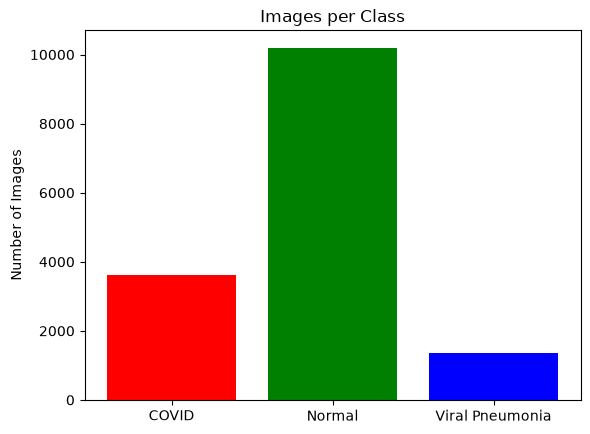

In [4]:
plt.bar(classes, counts, color= ['red', 'green', 'blue'])
plt.title("Images per Class")
plt.ylabel("Number of Images")
plt.show()

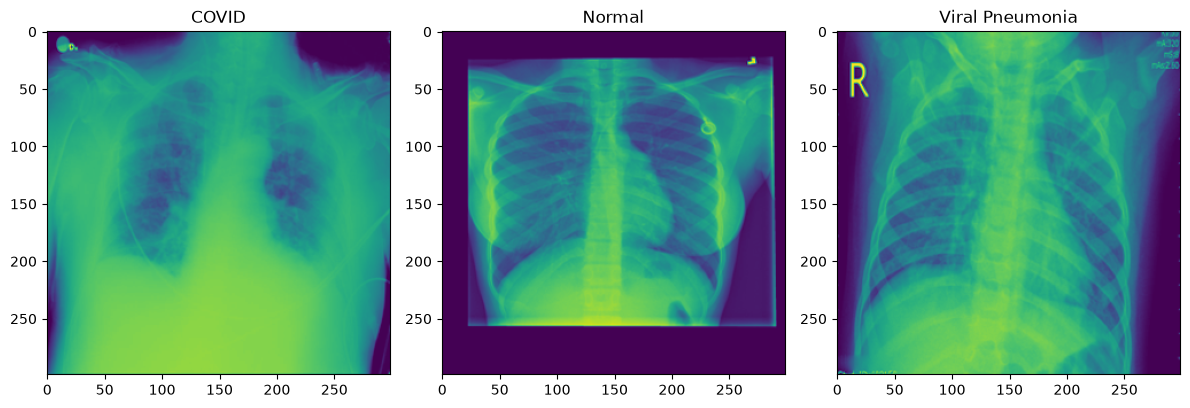

In [5]:
plt.figure(figsize = (12, 4))
for i, class_name in enumerate(classes):
        folder = os.path.join(dataset_path, class_name, "images" )
        filename = os.listdir(folder)[0]
        full_path = os.path.join(folder, filename)
        image = PIL.Image.open(full_path)
        plt.subplot(1,3, i + 1)
        plt.imshow(image)
        plt.title(class_name)
plt.tight_layout()
plt.show()

 Step 2: Data Loading (PyTorch Dataset, Transforms & DataLoader)v

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from glob import glob

In [ ]:
class_to_idx = {"COVID": 0, "Normal": 1, "Viral Pneumonia": 2}

class ChestXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transforms = None):
        self.image_paths = image_paths
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = PIL.Image.open(img_path).convert('RGB')

        if self.transforms:
            image = self.transforms(image)
        
        return image, torch.tensor(label, dtype=torch.long)

In [9]:
all_image_paths = []
all_labels = []

for class_name, label_idx in class_to_idx.items():
    folder = os.path.join(dataset_path, class_name, "images")
    for img_name in os.listdir(folder):
        if img_name.endswith('.png'):
            all_image_paths.append(os.path.join(folder, img_name))
            all_labels.append(label_idx)

print(f"Total images collected: {len(all_image_paths)}")
print(f"Total labels collected: {len(all_labels)}")

Total images collected: 15153
Total labels collected: 15153


In [14]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std= [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined successfully!")

Transforms defined successfully!
